# Notebook 01 - Exploratory Data Analysis

Tujuan: memahami karakteristik dataset MovieLens `ml-latest` secara menyeluruh
sebelum masuk ke feature engineering dan modeling.

Outline:
1. Setup & pembacaan data (Parquet hasil `src/data_loader.py`).
2. Ringkasan jumlah baris, user, film, rentang tahun, sparsity.
3. Distribusi rating & bias per user / per film.
4. Long-tail user dan item (log-log plot).
5. Evolusi temporal aktivitas & rata-rata rating.
6. Analisis genre: popularitas, rata-rata rating, tren dekade.
7. Cold-start analysis: proporsi user / film dengan interaksi sedikit.
8. Insight bisnis & ringkasan.


## 1. Setup & Loader

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150

FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

from src.data_loader import DataPaths, load_ratings_parquet

PATHS = DataPaths(
    raw_dir=ROOT / "ml-latest",
    processed_dir=ROOT / "data" / "processed",
    samples_dir=ROOT / "data" / "samples",
)

def savefig(name):
    out = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(out, bbox_inches="tight")
    print(f"  saved -> {out.relative_to(ROOT)}")


## 2. Ringkasan ukuran dataset

In [2]:
ratings_lf = load_ratings_parquet(PATHS)
# Materialize kolom minimal ke memori agar query berikutnya tidak full-scan berulang
ratings = ratings_lf.select("userId", "movieId", "rating", "rated_at").collect()
print(f"ratings in-memory: {ratings.estimated_size('mb'):.0f} MB, shape={ratings.shape}")
ratings_lf = ratings.lazy()
movies = pl.read_parquet(PATHS.processed_dir / "movies.parquet")
tags = pl.read_parquet(PATHS.processed_dir / "tags.parquet")
genome_scores_lf = pl.scan_parquet(PATHS.processed_dir / "genome_scores.parquet")
genome_tags = pl.read_parquet(PATHS.processed_dir / "genome_tags.parquet")

n_ratings = ratings_lf.select(pl.len()).collect().item()
n_users = ratings_lf.select(pl.col("userId").n_unique()).collect().item()
n_movies_rated = ratings_lf.select(pl.col("movieId").n_unique()).collect().item()
year_min = ratings_lf.select(pl.col("rated_at").dt.year().min()).collect().item()
year_max = ratings_lf.select(pl.col("rated_at").dt.year().max()).collect().item()

density = n_ratings / (n_users * n_movies_rated)
print(f"Ratings         : {n_ratings:,}")
print(f"Users           : {n_users:,}")
print(f"Movies (rated)  : {n_movies_rated:,}")
print(f"Movies (catalog): {movies.height:,}")
print(f"Tag free        : {tags.height:,}")
print(f"Genome tags     : {genome_tags.height:,}")
print(f"Year range      : {year_min} .. {year_max}")
print(f"Density (nnz/UI): {density:.3e}")
print(f"Sparsity        : {1 - density:.8f}")


ratings in-memory: 645 MB, shape=(33832162, 4)


Ratings         : 33,832,162
Users           : 330,975
Movies (rated)  : 83,239
Movies (catalog): 86,537
Tag free        : 2,328,315
Genome tags     : 1,128
Year range      : 1995 .. 2023
Density (nnz/UI): 1.228e-03
Sparsity        : 0.99877197


## 3. Distribusi rating

  saved -> reports\figures\01_rating_distribution.png


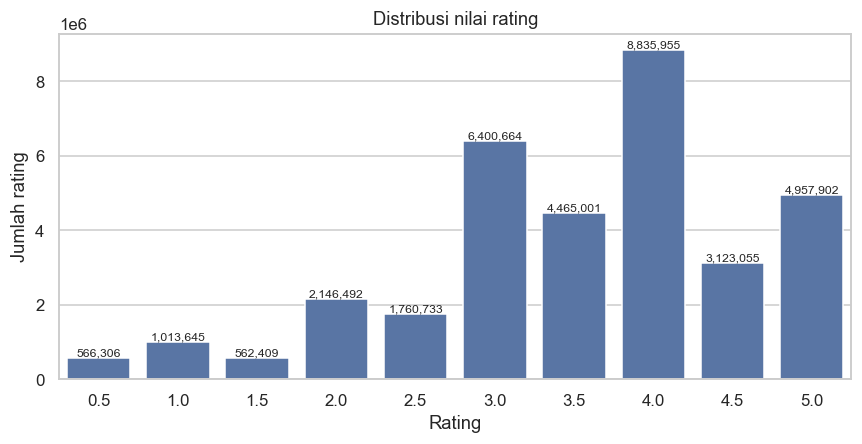

Mean rating   : 3.5425
Median rating : 4.00


In [3]:
rating_dist = (
    ratings_lf.group_by("rating")
    .agg(pl.len().alias("count"))
    .sort("rating")
    .collect()
)
rating_dist_pd = rating_dist.to_pandas()

fig, ax = plt.subplots(figsize=(8, 4.2))
sns.barplot(data=rating_dist_pd, x="rating", y="count", ax=ax, color="#4C72B0")
ax.set_title("Distribusi nilai rating")
ax.set_ylabel("Jumlah rating")
ax.set_xlabel("Rating")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", (p.get_x()+p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=8, rotation=0)
savefig("01_rating_distribution.png")
plt.show()

mean_overall = ratings_lf.select(pl.col("rating").mean()).collect().item()
median_overall = ratings_lf.select(pl.col("rating").median()).collect().item()
print(f"Mean rating   : {mean_overall:.4f}")
print(f"Median rating : {median_overall:.2f}")


## 4. Long-tail user & film (log-log)

  saved -> reports\figures\02_longtail_user_item.png


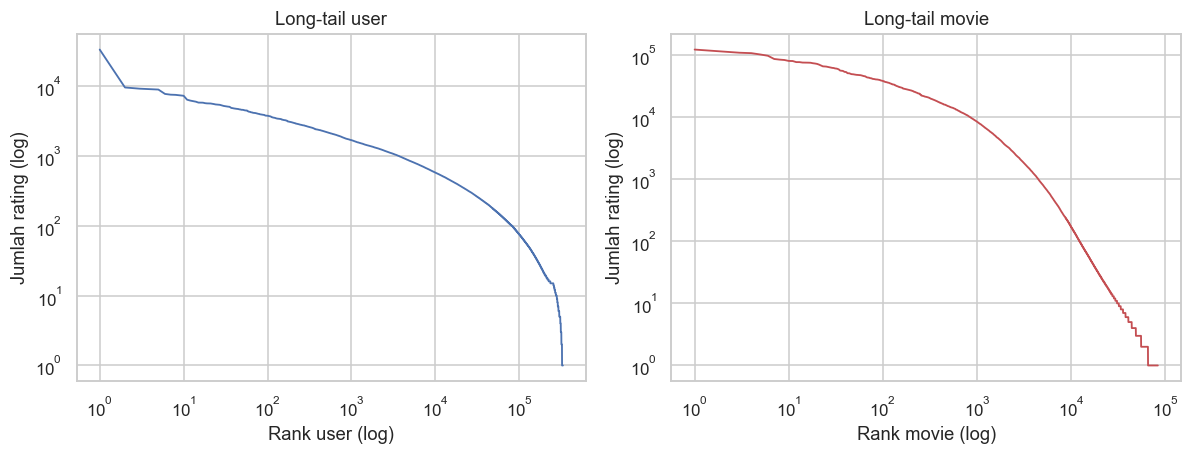

User p50 / p90 / p99 : [  31  250 1046]
Item p50 / p90 / p99 : [    5   263 10068]
Max user ratings     : 33,332
Max item ratings     : 122,296


In [4]:
user_counts = (
    ratings_lf.group_by("userId").agg(pl.len().alias("n")).collect()["n"].to_numpy()
)
item_counts = (
    ratings_lf.group_by("movieId").agg(pl.len().alias("n")).collect()["n"].to_numpy()
)

def long_tail_axes(ax, counts, label, color):
    counts_sorted = np.sort(counts)[::-1]
    rank = np.arange(1, len(counts_sorted) + 1)
    ax.loglog(rank, counts_sorted, color=color, lw=1.2)
    ax.set_xlabel(f"Rank {label} (log)")
    ax.set_ylabel("Jumlah rating (log)")
    ax.set_title(f"Long-tail {label}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
long_tail_axes(axes[0], user_counts, "user", "#4C72B0")
long_tail_axes(axes[1], item_counts, "movie", "#C44E52")
savefig("02_longtail_user_item.png")
plt.show()

print(f"User p50 / p90 / p99 : {np.percentile(user_counts,[50,90,99]).astype(int)}")
print(f"Item p50 / p90 / p99 : {np.percentile(item_counts,[50,90,99]).astype(int)}")
print(f"Max user ratings     : {int(user_counts.max()):,}")
print(f"Max item ratings     : {int(item_counts.max()):,}")


## 5. Evolusi temporal aktivitas rating

  saved -> reports\figures\03_temporal_activity.png


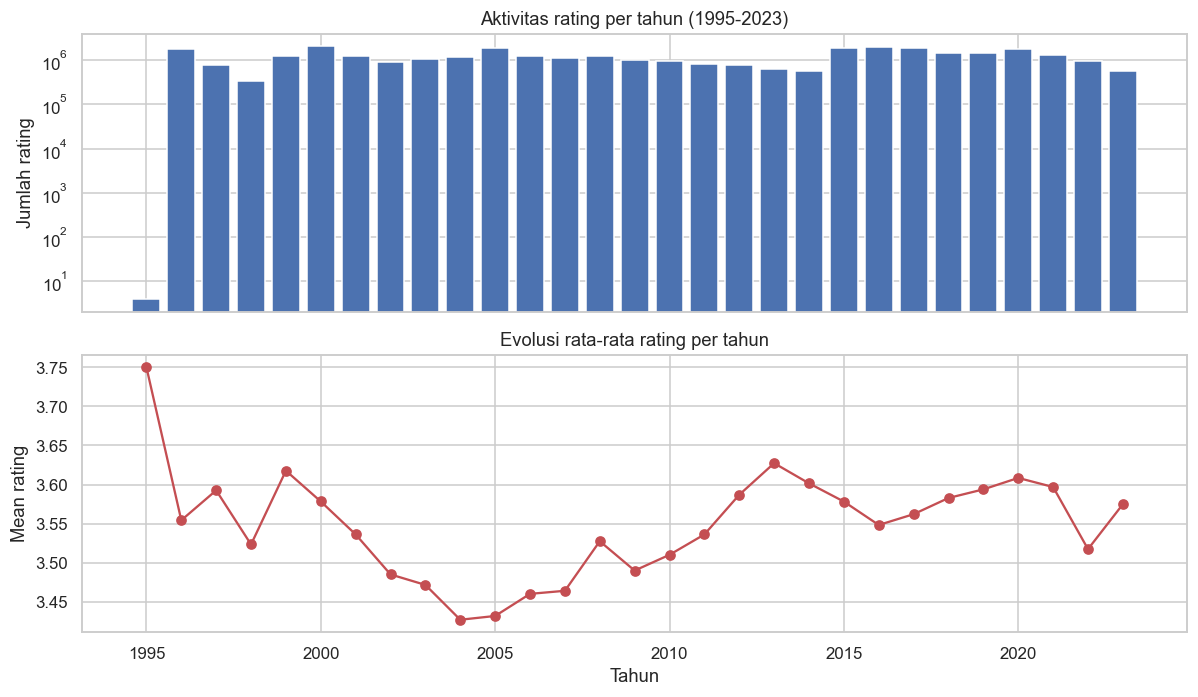

,year,n,mean_rating
19,2014,566628,3.601572
20,2015,1853975,3.578271
21,2016,2005979,3.548368
22,2017,1899523,3.562181
23,2018,1455193,3.582864
24,2019,1450218,3.593879
25,2020,1763532,3.608508
26,2021,1297525,3.596874
27,2022,953347,3.517503
28,2023,562624,3.574917


In [5]:
yearly = (
    ratings_lf.group_by(pl.col("rated_at").dt.year().alias("year"))
    .agg(pl.len().alias("n"), pl.col("rating").mean().alias("mean_rating"))
    .sort("year")
    .collect()
    .to_pandas()
)

fig, axes = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True)
axes[0].bar(yearly["year"], yearly["n"], color="#4C72B0")
axes[0].set_ylabel("Jumlah rating")
axes[0].set_title("Aktivitas rating per tahun (1995-2023)")
axes[0].set_yscale("log")

axes[1].plot(yearly["year"], yearly["mean_rating"], marker="o", color="#C44E52")
axes[1].set_ylabel("Mean rating")
axes[1].set_xlabel("Tahun")
axes[1].set_title("Evolusi rata-rata rating per tahun")
savefig("03_temporal_activity.png")
plt.show()
yearly.tail(10)


## 6. Bias user & item (heatmap 2D)

  saved -> reports\figures\04_bias_heatmaps.png


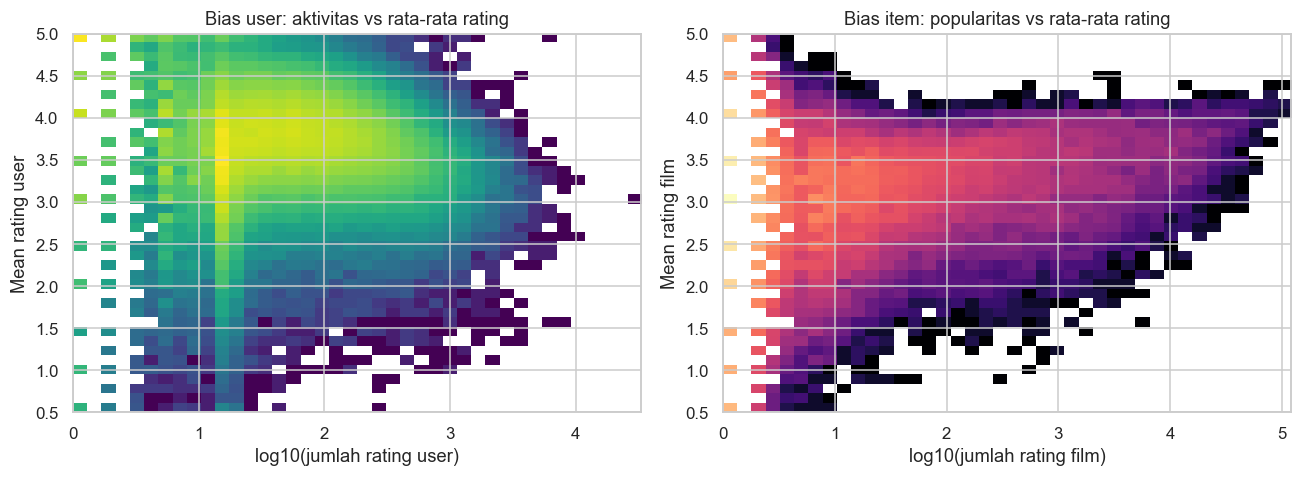

User mean rating (p10/p50/p90): [3.    3.721 4.418]
Item mean rating (p10/p50/p90): [2.    3.083 3.875]


In [6]:
user_stats = (
    ratings_lf.group_by("userId")
    .agg(pl.len().alias("n"), pl.col("rating").mean().alias("mean_rating"))
    .collect()
)
item_stats = (
    ratings_lf.group_by("movieId")
    .agg(pl.len().alias("n"), pl.col("rating").mean().alias("mean_rating"))
    .collect()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Heatmap user: n_ratings (log bin) vs mean_rating
u = user_stats.with_columns(
    pl.col("n").log10().alias("log_n"),
).to_pandas()
u_hist, xedges, yedges = np.histogram2d(
    u["log_n"], u["mean_rating"],
    bins=[40, 40], range=[[0, u["log_n"].max()], [0.5, 5]]
)
axes[0].imshow(u_hist.T, origin="lower", aspect="auto",
               extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
               cmap="viridis", norm="log")
axes[0].set_xlabel("log10(jumlah rating user)")
axes[0].set_ylabel("Mean rating user")
axes[0].set_title("Bias user: aktivitas vs rata-rata rating")

i = item_stats.with_columns(pl.col("n").log10().alias("log_n")).to_pandas()
i_hist, xedges, yedges = np.histogram2d(
    i["log_n"], i["mean_rating"],
    bins=[40, 40], range=[[0, i["log_n"].max()], [0.5, 5]]
)
axes[1].imshow(i_hist.T, origin="lower", aspect="auto",
               extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
               cmap="magma", norm="log")
axes[1].set_xlabel("log10(jumlah rating film)")
axes[1].set_ylabel("Mean rating film")
axes[1].set_title("Bias item: popularitas vs rata-rata rating")
savefig("04_bias_heatmaps.png")
plt.show()

print("User mean rating (p10/p50/p90):", np.percentile(user_stats["mean_rating"], [10,50,90]).round(3))
print("Item mean rating (p10/p50/p90):", np.percentile(item_stats["mean_rating"], [10,50,90]).round(3))


## 7. Analisis genre

  saved -> reports\figures\05_genre_popularity_mean.png


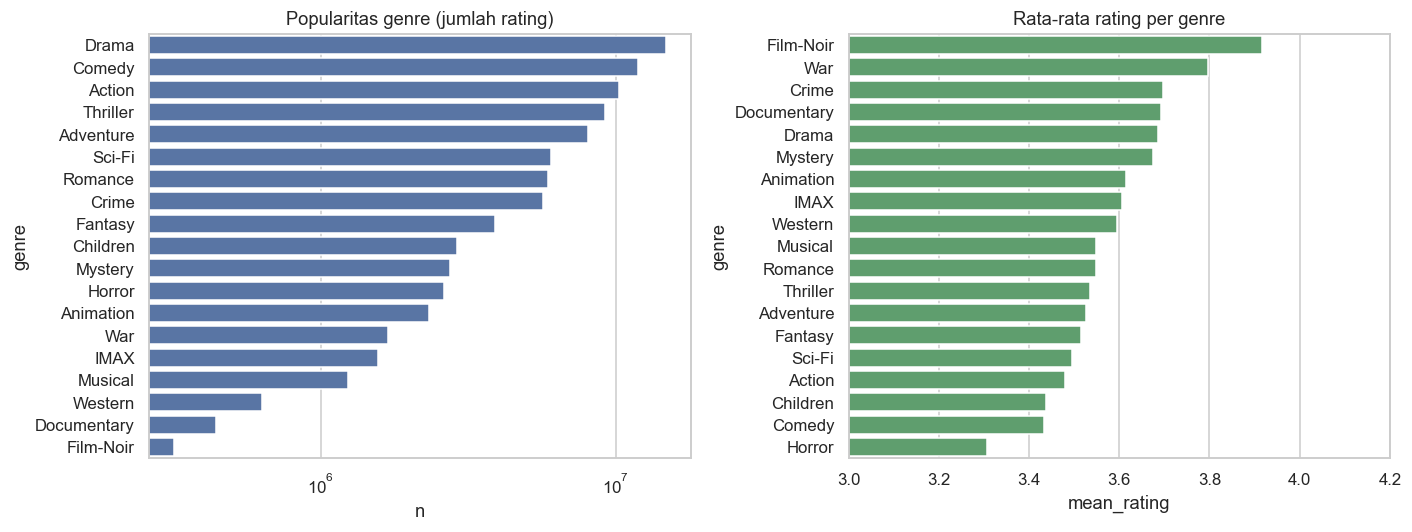

,genre,n,mean_rating
0,Drama,14787040,3.685839
1,Comedy,11860141,3.432232
2,Action,10222144,3.479978
3,Thriller,9168628,3.534075
4,Adventure,8048929,3.526007
5,Sci-Fi,6032230,3.494372
6,Romance,5874531,3.547334
7,Crime,5688582,3.697200
8,Fantasy,3899930,3.514349
9,Children,2897960,3.437728


In [7]:
movies_genre = movies.with_columns(
    pl.col("genres").str.split("|").alias("genre_list")
).explode("genre_list").rename({"genre_list": "genre"})
movies_genre = movies_genre.filter(pl.col("genre") != "(no genres listed)")

genre_agg = (
    ratings_lf.join(movies_genre.lazy().select("movieId", "genre"), on="movieId")
    .group_by("genre")
    .agg(pl.len().alias("n"), pl.col("rating").mean().alias("mean_rating"))
    .sort("n", descending=True)
    .collect()
    .to_pandas()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(data=genre_agg, y="genre", x="n", ax=axes[0], color="#4C72B0")
axes[0].set_title("Popularitas genre (jumlah rating)")
axes[0].set_xscale("log")
sns.barplot(data=genre_agg.sort_values("mean_rating", ascending=False),
            y="genre", x="mean_rating", ax=axes[1], color="#55A868")
axes[1].set_title("Rata-rata rating per genre")
axes[1].set_xlim(3, 4.2)
savefig("05_genre_popularity_mean.png")
plt.show()
genre_agg.head(15)


## 8. Tren genre per dekade rilis

  saved -> reports\figures\06_genre_decade_heatmap.png


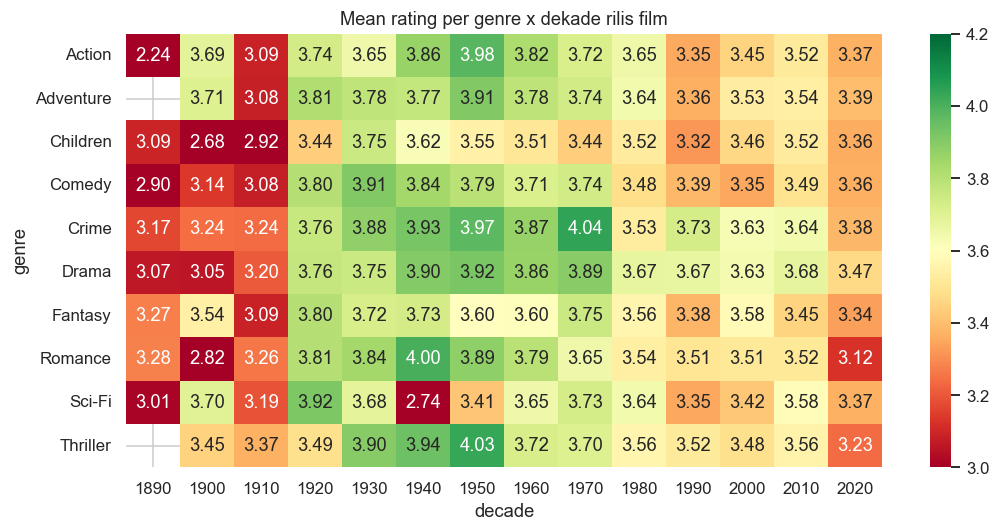

In [8]:
# Tren rating per dekade film, pakai tahun rilis dari judul
import re
year_pat = re.compile(r"\((\d{4})\)")

def extract_year(title):
    m = year_pat.search(title or "")
    return int(m.group(1)) if m else None

import numpy as np
release_years = movies["title"].to_list()
years_arr = np.array([
    int(m.group(1)) if (m := year_pat.search(t or "")) else -1 for t in release_years
], dtype=np.int32)
movies_year = movies.with_columns(pl.Series("release_year", years_arr)).filter(
    pl.col("release_year") > 0
)
movies_year = movies_year.with_columns(
    ((pl.col("release_year") // 10) * 10).alias("decade")
)

# Hindari double-join 33M rows: reduksi dulu ke level movieId baru merge metadata
movie_agg = (
    ratings_lf.group_by("movieId")
    .agg(pl.len().alias("n"), pl.col("rating").sum().alias("rsum"))
    .collect()
)
movie_agg = movie_agg.join(movies_year.select("movieId", "decade"), on="movieId")
movie_agg = movie_agg.join(movies_genre.select("movieId", "genre"), on="movieId")
decade_genre = (
    movie_agg.group_by(["decade", "genre"])
    .agg(pl.col("rsum").sum().alias("rsum"), pl.col("n").sum().alias("n"))
    .with_columns((pl.col("rsum") / pl.col("n")).alias("mean_rating"))
    .to_pandas()
)
top_genres = genre_agg["genre"].head(10).tolist()
pivot = (decade_genre[decade_genre["genre"].isin(top_genres)]
         .pivot_table(index="decade", columns="genre", values="mean_rating"))
pivot = pivot.sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot.T, annot=True, fmt=".2f", cmap="RdYlGn", vmin=3.0, vmax=4.2, ax=ax)
ax.set_title("Mean rating per genre x dekade rilis film")
savefig("06_genre_decade_heatmap.png")
plt.show()


## 9. Cold-start analysis

User dengan <5 rating   : 7.12%
User dengan <10 rating  : 15.51%
Film dengan <5 rating   : 47.29%
Film dengan <10 rating  : 61.53%
Film tanpa rating sama sekali: 3.81%


  saved -> reports\figures\07_coldstart_histograms.png


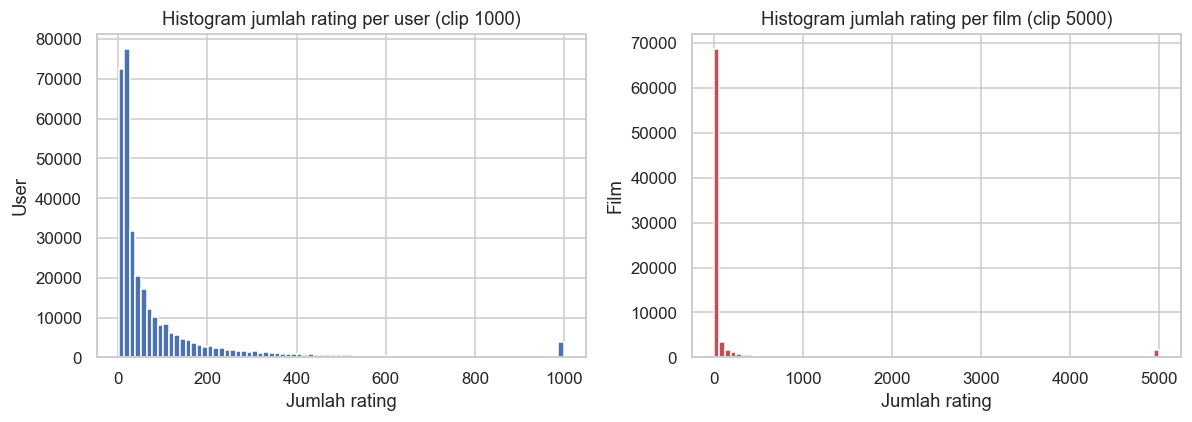

In [9]:
pct_user_lt5 = (user_stats["n"] < 5).sum() / user_stats.height * 100
pct_user_lt10 = (user_stats["n"] < 10).sum() / user_stats.height * 100
pct_item_lt10 = (item_stats["n"] < 10).sum() / item_stats.height * 100
pct_item_lt5 = (item_stats["n"] < 5).sum() / item_stats.height * 100
pct_item_0 = (movies.height - item_stats.height) / movies.height * 100

print(f"User dengan <5 rating   : {pct_user_lt5:.2f}%")
print(f"User dengan <10 rating  : {pct_user_lt10:.2f}%")
print(f"Film dengan <5 rating   : {pct_item_lt5:.2f}%")
print(f"Film dengan <10 rating  : {pct_item_lt10:.2f}%")
print(f"Film tanpa rating sama sekali: {pct_item_0:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(np.clip(user_stats["n"].to_numpy(), 1, 1000), bins=80, color="#4C72B0")
axes[0].set_title("Histogram jumlah rating per user (clip 1000)")
axes[0].set_xlabel("Jumlah rating"); axes[0].set_ylabel("User")
axes[1].hist(np.clip(item_stats["n"].to_numpy(), 1, 5000), bins=80, color="#C44E52")
axes[1].set_title("Histogram jumlah rating per film (clip 5000)")
axes[1].set_xlabel("Jumlah rating"); axes[1].set_ylabel("Film")
savefig("07_coldstart_histograms.png")
plt.show()


## 10. Density vs sparsity

  saved -> reports\figures\08_density_sparsity.png


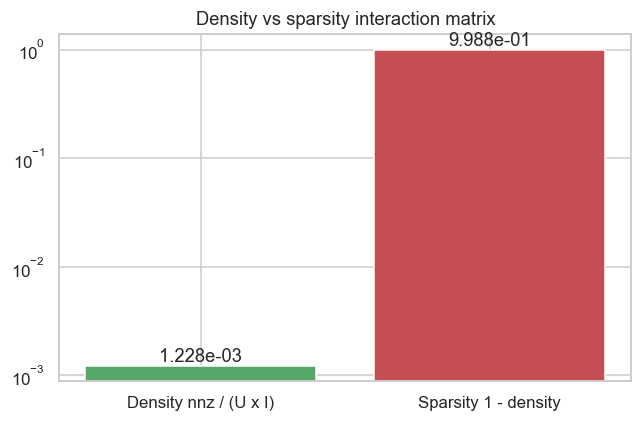

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
labels = ["Density nnz / (U x I)", "Sparsity 1 - density"]
values = [density, 1 - density]
ax.bar(labels, values, color=["#55A868", "#C44E52"])
ax.set_yscale("log")
for i, v in enumerate(values):
    ax.text(i, v, f"{v:.3e}", ha="center", va="bottom")
ax.set_title("Density vs sparsity interaction matrix")
savefig("08_density_sparsity.png")
plt.show()


## 11. Film 'underrated' di high-volume

In [11]:
# Top 15 film underrated: banyak rating tapi rata-rata relatif tinggi di kategori
# high-volume. Kriteria: n_ratings >= p90 popularitas DAN mean_rating >= 4.3.
p90_n = np.percentile(item_stats["n"].to_numpy(), 90)
candidates = item_stats.filter((pl.col("n") >= p90_n) & (pl.col("mean_rating") >= 4.3))
underrated = (
    candidates.sort("mean_rating", descending=True)
    .head(15)
    .join(movies.lazy().collect(), on="movieId", how="left")
    .select("title", "genres", "n", "mean_rating")
)
print("Film paling disukai di kategori high-volume (mean >= 4.3):")
underrated


Film paling disukai di kategori high-volume (mean >= 4.3):


title,genres,n,mean_rating
str,str,u32,f32
"""Planet Earth II (2016)""","""Documentary""",2041,4.451739
"""Planet Earth (2006)""","""Documentary""",3015,4.448093
"""Band of Brothers (2001)""","""Action|Drama|War""",2835,4.423986
"""Shawshank Redemption, The (199…","""Crime|Drama""",122296,4.416792
"""Cosmos""","""(no genres listed)""",625,4.3432
"""Parasite (2019)""","""Comedy|Drama""",12399,4.329946
"""Godfather, The (1972)""","""Crime|Drama""",75004,4.326602
"""Blue Planet II (2017)""","""Documentary""",1267,4.312944
"""Twelve Angry Men (1954)""","""Drama""",332,4.305723


## 12. Heavy vs casual users

Heavy users (>= p95 = 421 ratings): 16,559  mean rating 3.403
Casual users (<= 20 ratings)        : 132,047  mean rating 3.680


  saved -> reports\figures\09_heavy_vs_casual.png


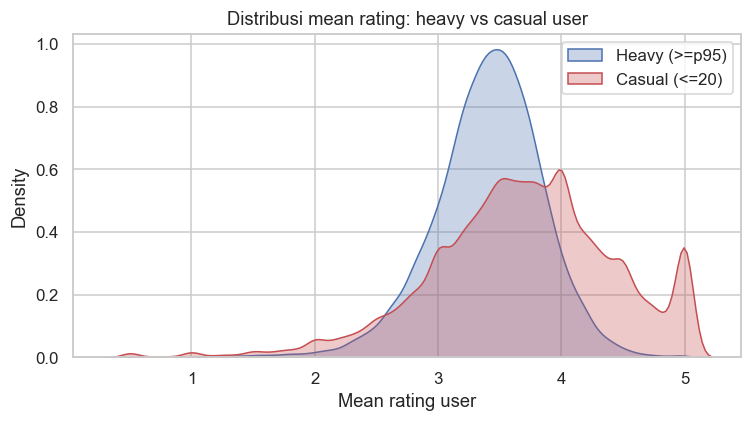

In [12]:
heavy_cut = np.percentile(user_stats["n"].to_numpy(), 95)
casual_cut = 20
heavy = user_stats.filter(pl.col("n") >= heavy_cut)
casual = user_stats.filter(pl.col("n") <= casual_cut)
print(f"Heavy users (>= p95 = {int(heavy_cut)} ratings): {heavy.height:,}  "
      f"mean rating {heavy['mean_rating'].mean():.3f}")
print(f"Casual users (<= {casual_cut} ratings)        : {casual.height:,}  "
      f"mean rating {casual['mean_rating'].mean():.3f}")

fig, ax = plt.subplots(figsize=(7, 4))
sns.kdeplot(heavy["mean_rating"].to_numpy(), ax=ax, label="Heavy (>=p95)", color="#4C72B0", fill=True, alpha=0.3)
sns.kdeplot(casual["mean_rating"].to_numpy(), ax=ax, label=f"Casual (<={casual_cut})", color="#C44E52", fill=True, alpha=0.3)
ax.set_title("Distribusi mean rating: heavy vs casual user")
ax.set_xlabel("Mean rating user"); ax.legend()
savefig("09_heavy_vs_casual.png")
plt.show()


## 13. Musiman: bulan & hari-dalam-minggu

  saved -> reports\figures\10_seasonality.png


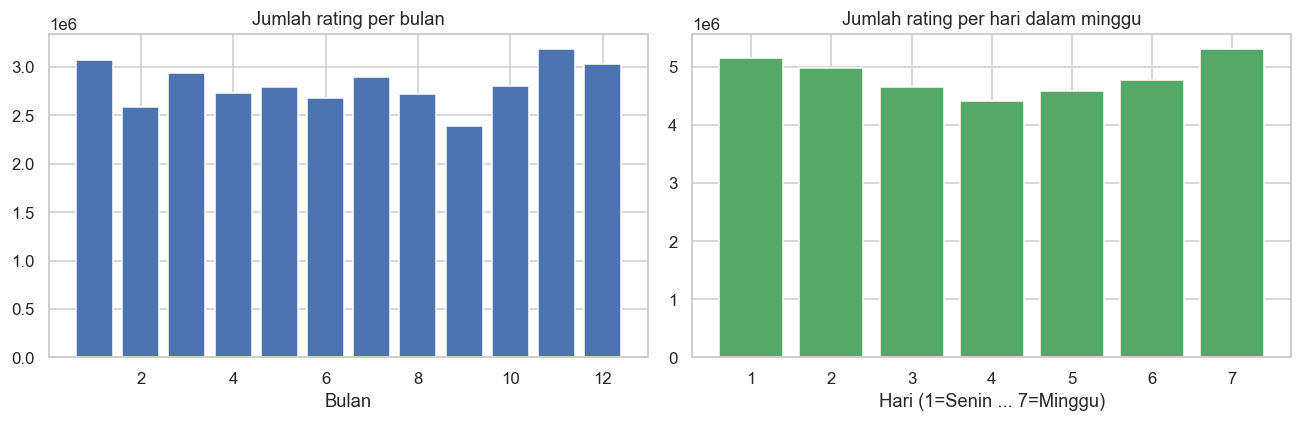

,month,n,mean_rating
0,1,3068454,3.541425
1,2,2582468,3.545823
2,3,2939293,3.511814
3,4,2732967,3.551593
4,5,2797095,3.544112
5,6,2683539,3.523229
6,7,2901447,3.532475
7,8,2724869,3.534590
8,9,2387774,3.542169
9,10,2801265,3.556878


In [13]:
monthly = (
    ratings_lf.group_by(pl.col("rated_at").dt.month().alias("month"))
    .agg(pl.len().alias("n"), pl.col("rating").mean().alias("mean_rating"))
    .sort("month").collect().to_pandas()
)
dow = (
    ratings_lf.group_by(pl.col("rated_at").dt.weekday().alias("dow"))
    .agg(pl.len().alias("n"), pl.col("rating").mean().alias("mean_rating"))
    .sort("dow").collect().to_pandas()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(monthly["month"], monthly["n"], color="#4C72B0")
axes[0].set_title("Jumlah rating per bulan"); axes[0].set_xlabel("Bulan")
axes[1].bar(dow["dow"], dow["n"], color="#55A868")
axes[1].set_title("Jumlah rating per hari dalam minggu")
axes[1].set_xlabel("Hari (1=Senin ... 7=Minggu)")
savefig("10_seasonality.png")
plt.show()
monthly


## 14. Free-text tags preview

  saved -> reports\figures\11_top_free_tags.png


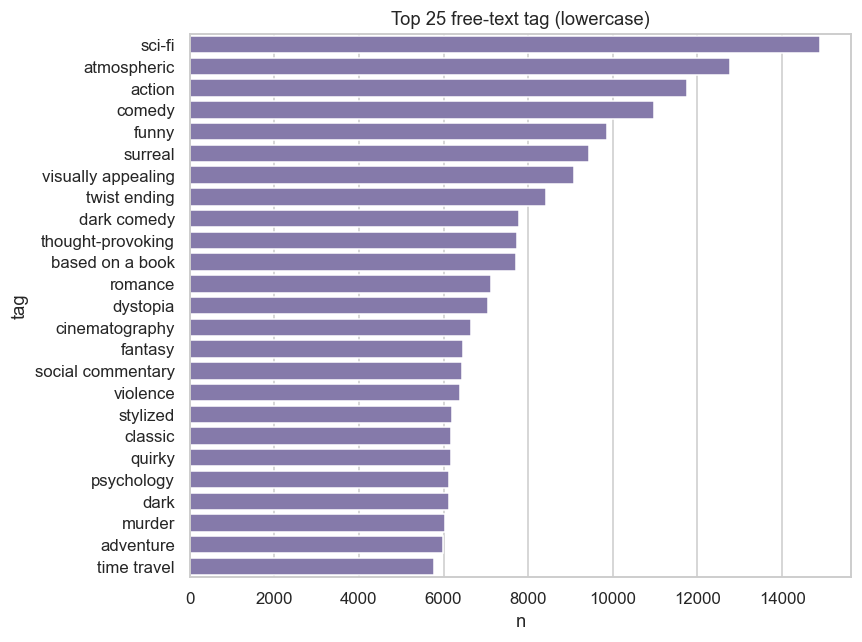

,tag,n
0,sci-fi,14892
1,atmospheric,12776
2,action,11747
3,comedy,10966
4,funny,9851
5,surreal,9443
6,visually appealing,9086
7,twist ending,8428
8,dark comedy,7777
9,thought-provoking,7731


In [14]:
top_tags_free = (
    tags.group_by(pl.col("tag").str.to_lowercase())
    .agg(pl.len().alias("n"))
    .sort("n", descending=True)
    .head(25).to_pandas()
)
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=top_tags_free, y="tag", x="n", ax=ax, color="#8172B2")
ax.set_title("Top 25 free-text tag (lowercase)")
savefig("11_top_free_tags.png")
plt.show()
top_tags_free.head(10)


## 15. Tag-genome relevance preview

  saved -> reports\figures\12_genome_relevance_dist.png


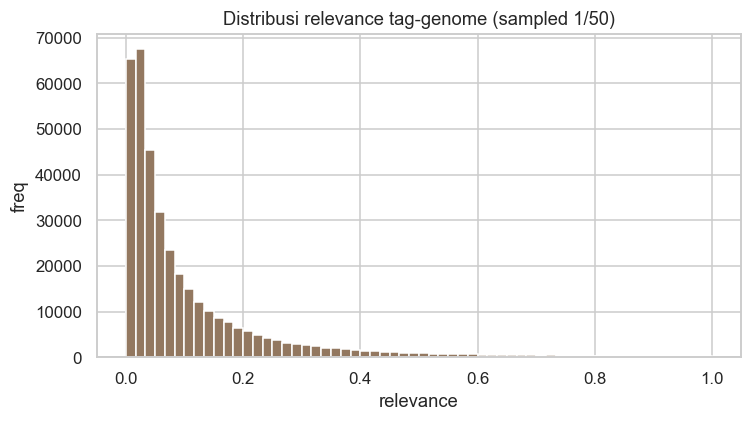

,tagId,mean_rel,tag
0,188,0.475596,catastrophe
1,195,0.359573,chase
2,270,0.376521,criterion
3,277,0.379729,culture clash
4,302,0.429372,dialogue
5,323,0.383739,drama
6,445,0.396630,good
7,452,0.409664,good soundtrack
8,464,0.377135,great
9,468,0.435187,great ending


In [15]:
# Distribusi relevance tag-genome (sampel streaming)
rel_sample = (
    genome_scores_lf.select("relevance")
    .filter(pl.int_range(0, pl.len()) % 50 == 0)  # downsample 1/50
    .collect()
)
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(rel_sample["relevance"].to_numpy(), bins=60, color="#937860")
ax.set_title("Distribusi relevance tag-genome (sampled 1/50)")
ax.set_xlabel("relevance"); ax.set_ylabel("freq")
savefig("12_genome_relevance_dist.png")
plt.show()

top_genome = (
    genome_scores_lf.group_by("tagId")
    .agg(pl.col("relevance").mean().alias("mean_rel"))
    .sort("mean_rel", descending=True).head(20).collect()
    .join(genome_tags.lazy().collect(), on="tagId")
)
top_genome.to_pandas()


## 16. Usia film saat di-rating

  saved -> reports\figures\13_movie_age_at_rating.png


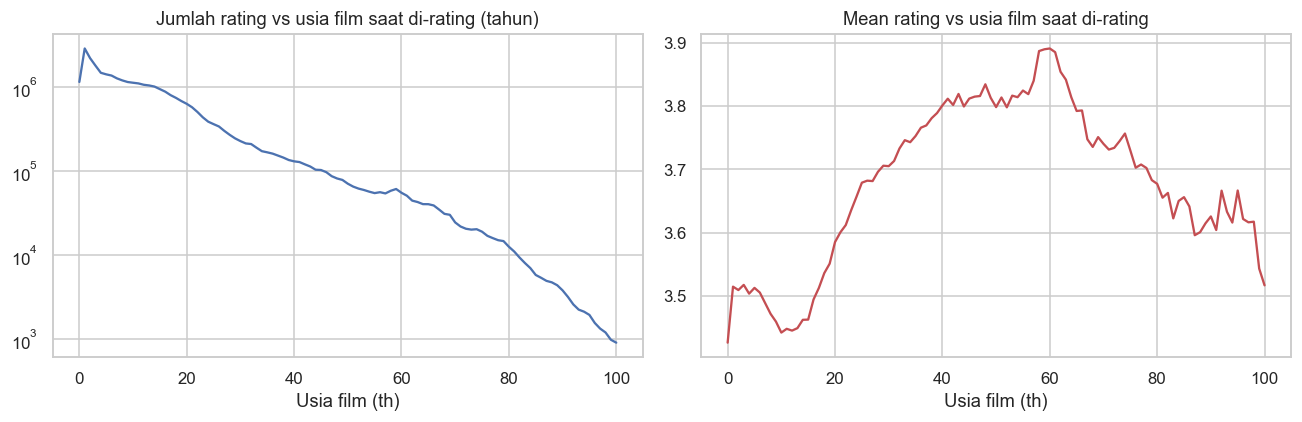

In [16]:
age_df = (
    ratings_lf.join(movies_year.lazy().select("movieId", "release_year"), on="movieId")
    .with_columns((pl.col("rated_at").dt.year() - pl.col("release_year")).alias("age"))
    .filter((pl.col("age") >= 0) & (pl.col("age") <= 100))
    .group_by("age").agg(pl.len().alias("n"), pl.col("rating").mean().alias("mean_rating"))
    .sort("age").collect(engine="streaming").to_pandas()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(age_df["age"], age_df["n"], color="#4C72B0")
axes[0].set_title("Jumlah rating vs usia film saat di-rating (tahun)")
axes[0].set_xlabel("Usia film (th)"); axes[0].set_yscale("log")
axes[1].plot(age_df["age"], age_df["mean_rating"], color="#C44E52")
axes[1].set_title("Mean rating vs usia film saat di-rating")
axes[1].set_xlabel("Usia film (th)")
savefig("13_movie_age_at_rating.png")
plt.show()


## 17. Jumlah genre per film

  saved -> reports\figures\14_n_genre_per_movie.png


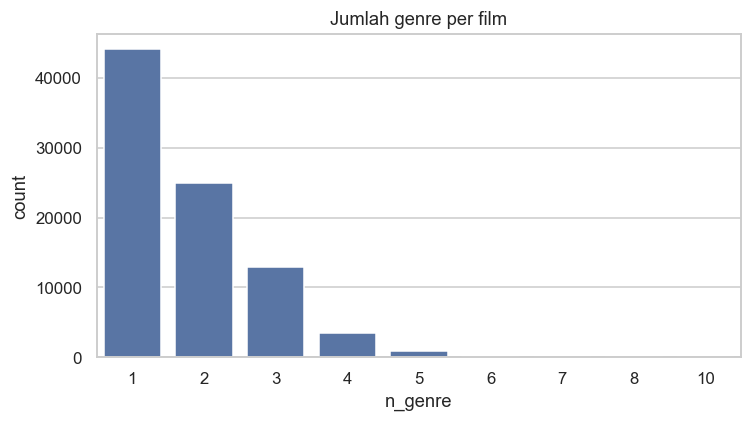

count    86537.000000
mean         1.759802
std          0.944122
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         10.000000
Name: n_genre, dtype: float64

In [17]:
n_genre_per_movie = (
    movies.with_columns(
        pl.col("genres").str.split("|").list.len().alias("n_genre")
    ).to_pandas()
)
fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=n_genre_per_movie, x="n_genre", ax=ax, color="#4C72B0")
ax.set_title("Jumlah genre per film")
savefig("14_n_genre_per_movie.png")
plt.show()
n_genre_per_movie["n_genre"].describe()


## 18. Ringkasan dataset (signature figure)

  saved -> reports\figures\15_dataset_summary.png


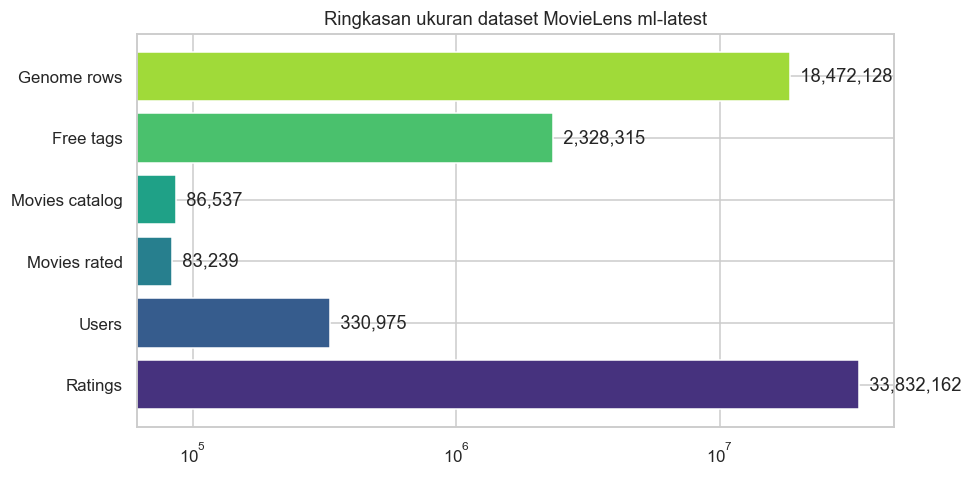

In [18]:
# Ringkasan metrik dataset dalam satu figure (signature portfolio)
summary = {
    "Ratings": n_ratings,
    "Users": n_users,
    "Movies rated": n_movies_rated,
    "Movies catalog": movies.height,
    "Free tags": tags.height,
    "Genome rows": int(genome_scores_lf.select(pl.len()).collect().item()),
}
fig, ax = plt.subplots(figsize=(9, 4.5))
keys = list(summary.keys()); vals = list(summary.values())
bars = ax.barh(keys, vals, color=sns.color_palette("viridis", len(keys)))
ax.set_xscale("log")
for bar, v in zip(bars, vals):
    ax.text(v, bar.get_y()+bar.get_height()/2, f"  {v:,}", va="center")
ax.set_title("Ringkasan ukuran dataset MovieLens ml-latest")
savefig("15_dataset_summary.png")
plt.show()


## Insight Bisnis Ringkas

1. **Skala & sparsity**: jutaan rating dari ratusan ribu user terhadap puluhan
   ribu film; matrix interaksi sangat jarang, sehingga metode matrix-factorization
   dan ANN retrieval (FAISS) menjadi pilihan wajar untuk skala ini.
2. **Long-tail kuat di kedua sisi**: sebagian kecil user mencatat rating sangat
   banyak, sementara mayoritas user hanya rating beberapa film; pola serupa pada
   film. Implikasi: perlu penanganan cold-start dan reranking berbasis popularity
   bucket.
3. **Bias rating tinggi**: distribusi rating tidak netral (kecenderungan ke nilai
   tinggi), jadi baseline global-mean & user/item-mean harus diukur sebagai
   kontrol sebelum klaim improvement model.
4. **Evolusi temporal**: aktivitas rating memuncak di periode tertentu, sehingga
   split train/test berbasis timestamp (leave-last-N-out per user) lebih realistis
   daripada random split.
5. **Genre & dekade**: genre tertentu (drama, documentary, film-noir) konsisten
   mendapat rating tinggi lintas dekade; genre populer belum tentu paling disukai.

Output gambar disimpan di `reports/figures/` dengan prefix `01_..15_`.
